# San Antonio Check Disbursements — Exploratory Analysis
**Source:** `data/raw/Check Disbursements_03_10_2026.csv`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

## Load & Inspect

In [2]:
df = pd.read_csv(
    '../data/raw/Check Disbursements_03_10_2026.csv',
    skiprows=1,  # first row is a grand-total line
)
df['Payment Amount'] = pd.to_numeric(df['Payment Amount'], errors='coerce')
print(f"Rows: {len(df):,}  |  Columns: {list(df.columns)}")
df.head(10)

Rows: 50,000  |  Columns: ['FiscalYear', 'Month', 'Payee', 'Service', 'Payment Amount']


,FiscalYear,Month,Payee,Service,Payment Amount
0,2026,February,ZW USA INC,Janitorial Supplies,1391.28
1,2026,February,ZOETIS US LLC,Chemicals Medical and Drugs,10008.45
2,2026,February,ZEP SALES & SERVICES,Janitorial Supplies,3213.42
3,2026,February,ZEITGEIST EXPRESSION,Fees to Professional Contractors,1800.00
4,2026,February,ZAPOPAN BUSINESS GRO,Office Supplies,109.90
5,2026,February,ZACKARY VARGAS,Transportation Fees,219.68
6,2026,February,ZACHMAN ENTERPRISES,Maintenance and Repair Building and Improvements,15830.00
7,2026,February,ZACHMAN ENTERPRISES,Construction Cost,86785.00
8,2026,February,ZACARIAS IZQUIERDO,General Liability Claims,3106.25
9,2026,February,YVONNE RAMIREZ,Transportation Fees,165.30


In [3]:
df.info()
print()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   FiscalYear      50000 non-null  int64  
 1   Month           50000 non-null  object 
 2   Payee           50000 non-null  object 
 3   Service         50000 non-null  object 
 4   Payment Amount  50000 non-null  float64
dtypes: float64(1), int64(1), object(3)
memory usage: 1.9+ MB



,FiscalYear,Payment Amount
count,50000.000000,5.000000e+04
mean,2025.148300,6.827109e+04
std,0.569696,1.083534e+06
min,2024.000000,-1.467108e+05
25%,2025.000000,3.639600e+02
50%,2025.000000,2.287730e+03
75%,2025.000000,1.207173e+04
max,2026.000000,1.115300e+08


In [4]:
print('Null counts:')
print(df.isnull().sum())
print(f"\nFiscal Years: {sorted(df['FiscalYear'].dropna().unique())}")
print(f"Months:       {df['Month'].dropna().unique().tolist()}")

Null counts:
FiscalYear        0
Month             0
Payee             0
Service           0
Payment Amount    0
dtype: int64

Fiscal Years: [2024, 2025, 2026]
Months:       ['February', 'January', 'December', 'November', 'October', 'September', 'August', 'July', 'June', 'May', 'April', 'March']


## Spending by Month

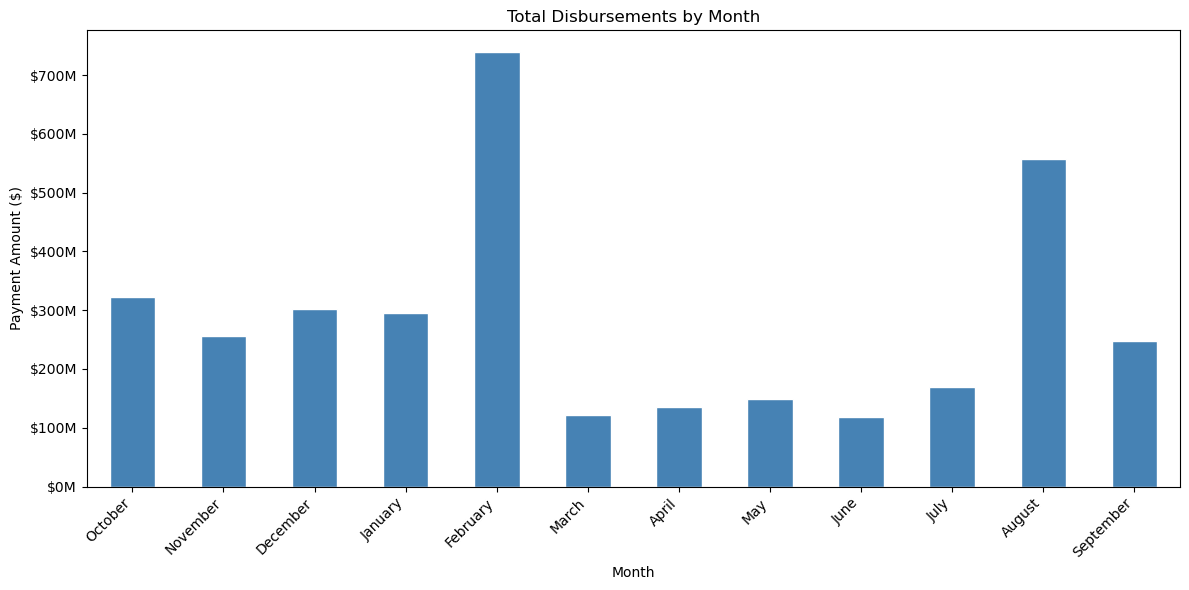

Month
October      $322,359,387.04
November     $256,120,429.41
December     $301,741,552.99
January      $295,127,684.22
February     $739,021,486.04
March        $121,644,098.02
April        $135,127,256.48
May          $149,510,749.68
June         $118,241,049.14
July         $169,670,808.75
August       $557,416,550.12
September    $247,573,456.19
Name: Payment Amount, dtype: object

In [5]:
month_order = ['October','November','December','January','February','March',
               'April','May','June','July','August','September']
monthly = df.groupby('Month')['Payment Amount'].sum().reindex(month_order).dropna()

ax = monthly.plot.bar(color='steelblue', edgecolor='white')
ax.set_title('Total Disbursements by Month')
ax.set_ylabel('Payment Amount ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
monthly.apply(lambda x: f'${x:,.2f}')

## Top 20 Payees

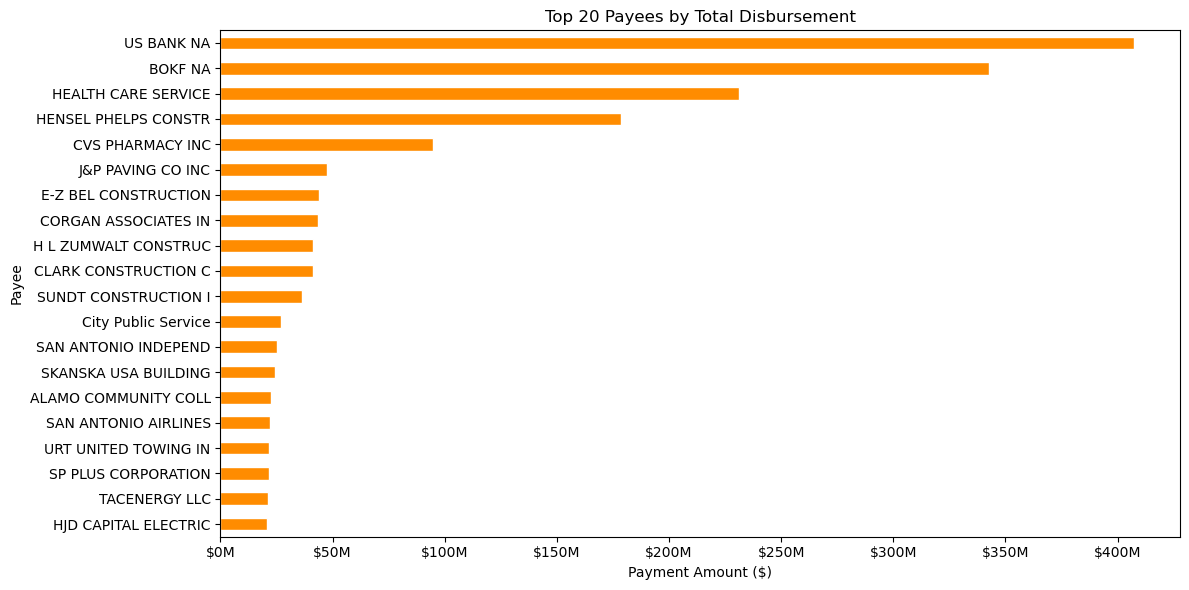

Payee
US BANK NA              $407,455,060.39
BOKF NA                 $342,767,570.93
HEALTH CARE SERVICE     $230,992,840.35
HENSEL PHELPS CONSTR    $178,690,017.83
CVS PHARMACY INC         $94,953,619.07
J&P PAVING CO INC        $47,720,793.95
E-Z BEL CONSTRUCTION     $43,864,963.26
CORGAN ASSOCIATES IN     $43,356,608.02
H L ZUMWALT CONSTRUC     $41,320,331.09
CLARK CONSTRUCTION C     $41,064,912.30
SUNDT CONSTRUCTION I     $36,570,676.04
City Public Service      $26,958,153.72
SAN ANTONIO INDEPEND     $25,092,826.66
SKANSKA USA BUILDING     $24,532,260.48
ALAMO COMMUNITY COLL     $22,456,965.85
SAN ANTONIO AIRLINES     $22,301,487.07
URT UNITED TOWING IN     $21,585,016.42
SP PLUS CORPORATION      $21,527,332.59
TACENERGY LLC            $21,392,866.69
HJD CAPITAL ELECTRIC     $20,871,071.61
Name: Payment Amount, dtype: object

In [6]:
top_payees = df.groupby('Payee')['Payment Amount'].sum().nlargest(20)

ax = top_payees.plot.barh(color='darkorange', edgecolor='white')
ax.set_title('Top 20 Payees by Total Disbursement')
ax.set_xlabel('Payment Amount ($)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
ax.invert_yaxis()
plt.tight_layout()
plt.show()
top_payees.apply(lambda x: f'${x:,.2f}')

## Top 20 Service Categories

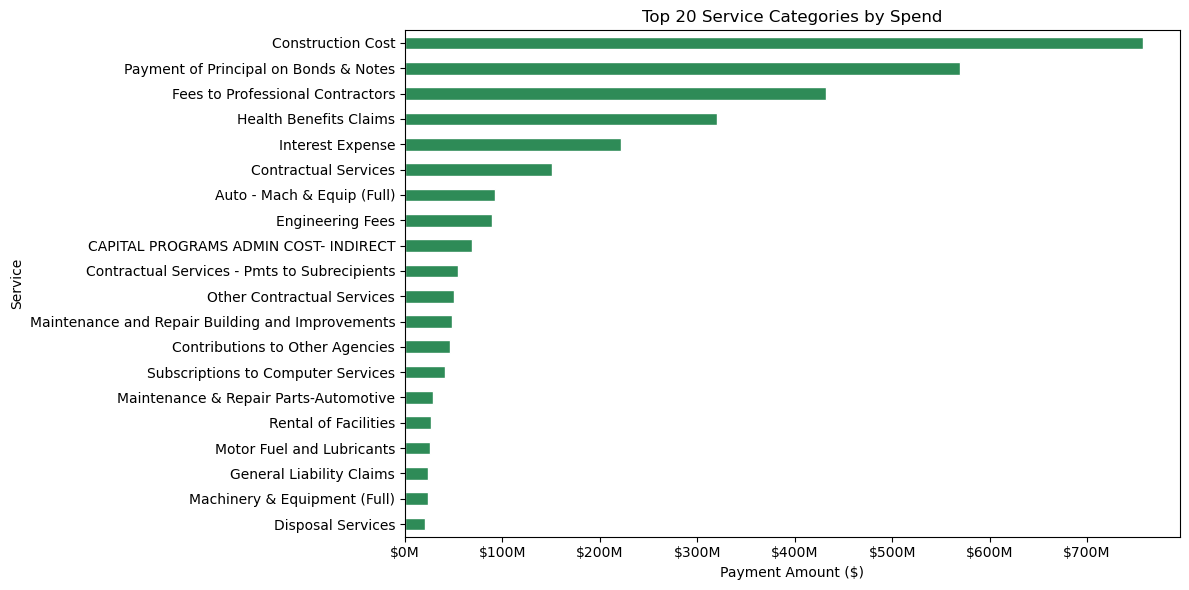

Service
Construction Cost                                   $757,512,796.58
Payment of Principal on Bonds & Notes               $569,720,000.00
Fees to Professional Contractors                    $432,054,466.02
Health Benefits Claims                              $319,813,619.89
Interest Expense                                    $222,245,010.63
Contractual Services                                $151,418,553.80
Auto - Mach & Equip (Full)                           $92,178,028.88
Engineering Fees                                     $89,479,459.39
CAPITAL PROGRAMS ADMIN COST- INDIRECT                $68,862,785.01
Contractual Services - Pmts to Subrecipients         $54,572,609.64
Other Contractual Services                           $50,404,649.54
Maintenance and Repair Building and Improvements     $48,419,497.34
Contributions to Other Agencies                      $46,209,308.40
Subscriptions to Computer Services                   $41,245,770.02
Maintenance & Repair Parts-Automotive   

In [7]:
top_services = df.groupby('Service')['Payment Amount'].sum().nlargest(20)

ax = top_services.plot.barh(color='seagreen', edgecolor='white')
ax.set_title('Top 20 Service Categories by Spend')
ax.set_xlabel('Payment Amount ($)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
ax.invert_yaxis()
plt.tight_layout()
plt.show()
top_services.apply(lambda x: f'${x:,.2f}')

## Quick Summary Stats

In [8]:
print(f"Total disbursed:      ${df['Payment Amount'].sum():,.2f}")
print(f"Unique payees:        {df['Payee'].nunique():,}")
print(f"Unique services:      {df['Service'].nunique():,}")
print(f"Median payment:       ${df['Payment Amount'].median():,.2f}")
print(f"Mean payment:         ${df['Payment Amount'].mean():,.2f}")
print(f"Max single payment:   ${df['Payment Amount'].max():,.2f}")

Total disbursed:      $3,413,554,508.08
Unique payees:        9,782
Unique services:      152
Median payment:       $2,287.73
Mean payment:         $68,271.09
Max single payment:   $111,530,000.00


## Vendor Concentration — How Concentrated Is City Spending?

A key question in public finance: **do a few vendors capture most of the money?**
This is measured with a [Lorenz curve](https://en.wikipedia.org/wiki/Lorenz_curve) and Gini coefficient — 
the same tools economists use to measure income inequality, applied here to city vendor payments.

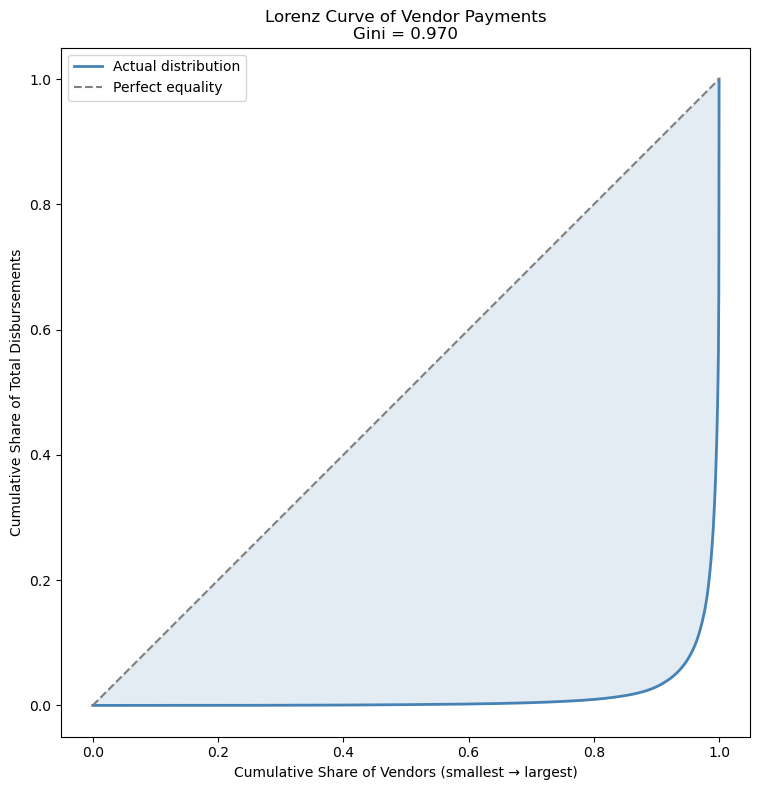

Total vendors (positive spend): 9,776
Top  1% of vendors (97 vendors) capture 72.8% of all spending
Top  5% of vendors (488 vendors) capture 92.6% of all spending
Top 10% of vendors (977 vendors) capture 97.0% of all spending

Gini coefficient: 0.970  (1.0 = one vendor gets everything, 0.0 = all vendors equal)


In [9]:
import numpy as np

# Total spend per vendor
vendor_totals = df.groupby('Payee')['Payment Amount'].sum().sort_values()
vendor_totals = vendor_totals[vendor_totals > 0]  # exclude negatives (refunds/credits)

# Lorenz curve data
cumulative_share = vendor_totals.cumsum() / vendor_totals.sum()
vendor_pct = np.linspace(0, 1, len(cumulative_share))

# Gini coefficient (area between Lorenz curve and equality line)
gini = 1 - 2 * np.trapz(cumulative_share.values, vendor_pct)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(vendor_pct, cumulative_share.values, color='steelblue', linewidth=2, label='Actual distribution')
ax.plot([0, 1], [0, 1], '--', color='gray', label='Perfect equality')
ax.fill_between(vendor_pct, cumulative_share.values, vendor_pct, alpha=0.15, color='steelblue')

ax.set_xlabel('Cumulative Share of Vendors (smallest → largest)')
ax.set_ylabel('Cumulative Share of Total Disbursements')
ax.set_title(f'Lorenz Curve of Vendor Payments\nGini = {gini:.3f}')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

# Key concentration stats
n = len(vendor_totals)
top_1pct = vendor_totals.tail(max(1, n // 100)).sum()
top_5pct = vendor_totals.tail(max(1, n // 20)).sum()
top_10pct = vendor_totals.tail(max(1, n // 10)).sum()
total = vendor_totals.sum()

print(f"Total vendors (positive spend): {n:,}")
print(f"Top  1% of vendors ({max(1,n//100):,} vendors) capture {top_1pct/total:.1%} of all spending")
print(f"Top  5% of vendors ({max(1,n//20):,} vendors) capture {top_5pct/total:.1%} of all spending")
print(f"Top 10% of vendors ({max(1,n//10):,} vendors) capture {top_10pct/total:.1%} of all spending")
print(f"\nGini coefficient: {gini:.3f}  (1.0 = one vendor gets everything, 0.0 = all vendors equal)")

## Payment Size Distribution — The "Long Tail" of City Checks

Most city checks are small, but a few are enormous. A log-scale histogram reveals the true shape of spending.

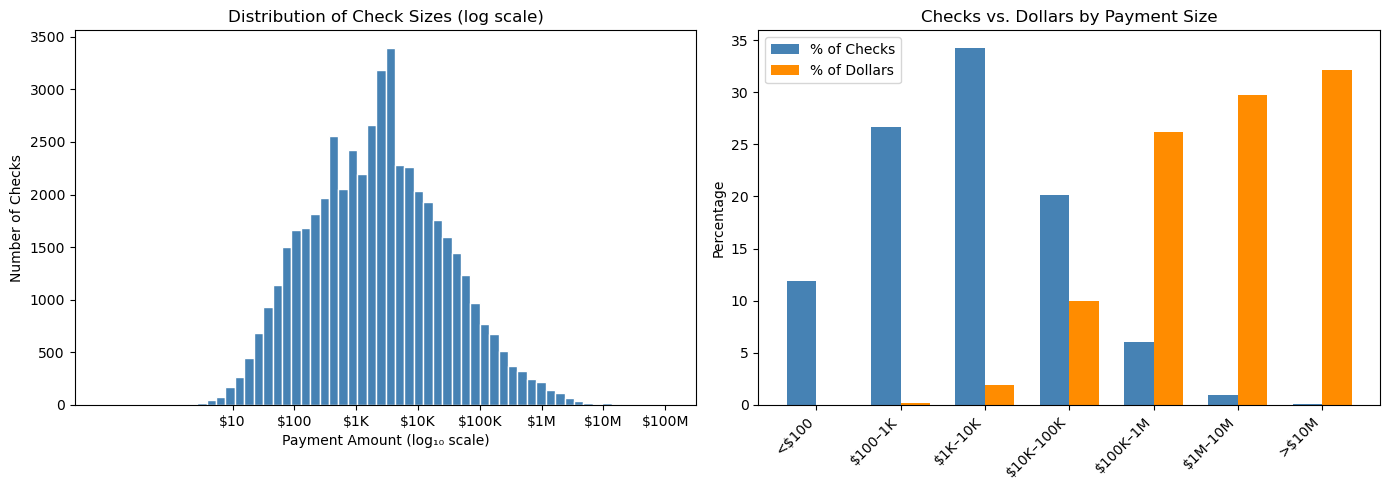

             count pct_of_count          total pct_of_dollars
size_bucket                                                  
<$100        5,924        11.9%       $302,008           0.0%
$100–1K     13,329        26.7%     $5,732,054           0.2%
$1K–10K     17,082        34.2%    $64,204,844           1.9%
$10K–100K   10,070        20.2%   $339,356,459           9.9%
$100K–1M     3,005         6.0%   $893,912,019          26.2%
$1M–10M        465         0.9% $1,014,074,881          29.7%
>$10M           41         0.1% $1,096,310,801          32.1%


In [10]:
positive = df[df['Payment Amount'] > 0]['Payment Amount']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log-scale histogram
axes[0].hist(np.log10(positive), bins=60, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Payment Amount (log₁₀ scale)')
axes[0].set_ylabel('Number of Checks')
axes[0].set_title('Distribution of Check Sizes (log scale)')
ticks = [1, 2, 3, 4, 5, 6, 7, 8]
axes[0].set_xticks(ticks)
axes[0].set_xticklabels(['$10', '$100', '$1K', '$10K', '$100K', '$1M', '$10M', '$100M'])

# Size bucket breakdown
bins = [0, 100, 1_000, 10_000, 100_000, 1_000_000, 10_000_000, float('inf')]
labels = ['<$100', '$100–1K', '$1K–10K', '$10K–100K', '$100K–1M', '$1M–10M', '>$10M']
df['size_bucket'] = pd.cut(positive, bins=bins, labels=labels)
bucket_stats = df.dropna(subset=['size_bucket']).groupby('size_bucket', observed=False).agg(
    count=('Payment Amount', 'count'),
    total=('Payment Amount', 'sum')
)
bucket_stats['pct_of_count'] = bucket_stats['count'] / bucket_stats['count'].sum() * 100
bucket_stats['pct_of_dollars'] = bucket_stats['total'] / bucket_stats['total'].sum() * 100

colors = ['#fee0d2', '#fcbba1', '#fc9272', '#fb6a4a', '#ef3b2c', '#cb181d', '#99000d']
x = range(len(labels))
w = 0.35
axes[1].bar([i - w/2 for i in x], bucket_stats['pct_of_count'], w, label='% of Checks', color='steelblue')
axes[1].bar([i + w/2 for i in x], bucket_stats['pct_of_dollars'], w, label='% of Dollars', color='darkorange')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=45, ha='right')
axes[1].set_ylabel('Percentage')
axes[1].set_title('Checks vs. Dollars by Payment Size')
axes[1].legend()

plt.tight_layout()
plt.show()

print(bucket_stats[['count', 'pct_of_count', 'total', 'pct_of_dollars']].to_string(
    formatters={
        'count': '{:,.0f}'.format,
        'pct_of_count': '{:.1f}%'.format,
        'total': '${:,.0f}'.format,
        'pct_of_dollars': '{:.1f}%'.format,
    }
))

## Spending DNA — What Does San Antonio Actually Buy?

Let's categorize every service into high-level themes to see the city's spending "personality."
This tells us whether SA is primarily a *builder*, a *service provider*, a *debt payer*, etc.

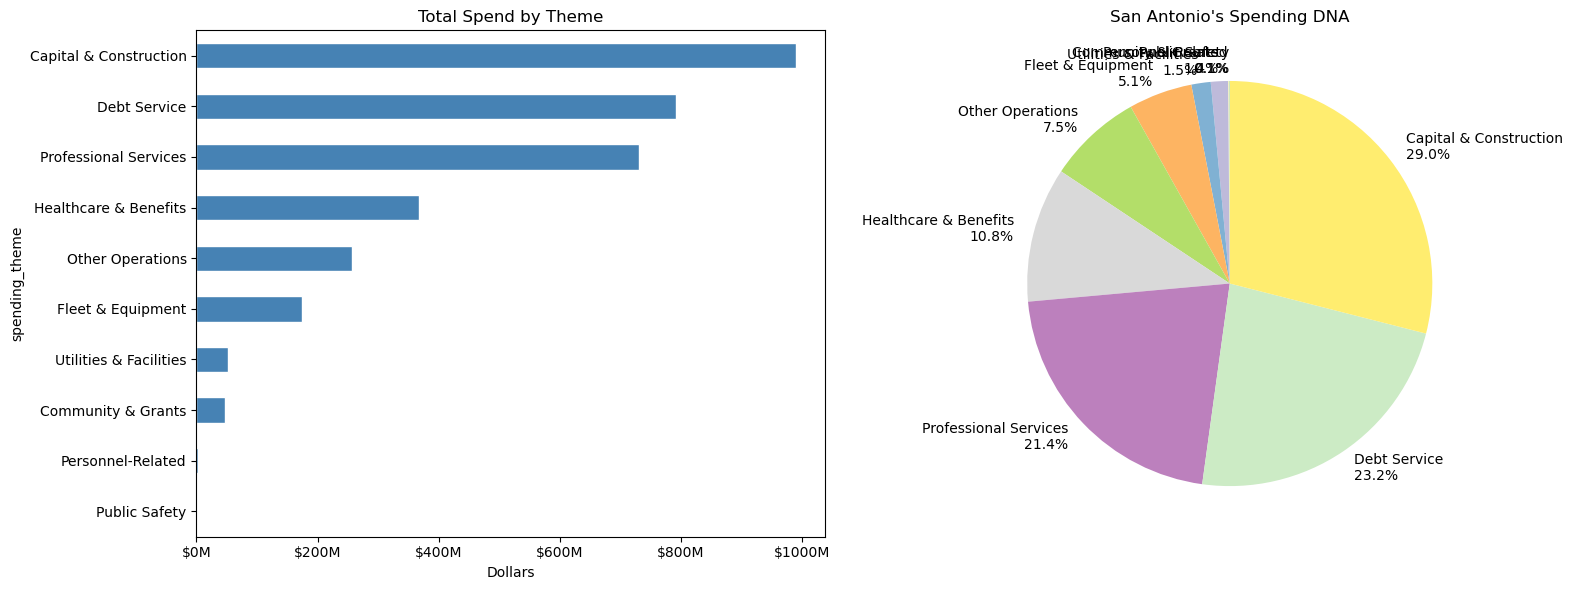

  Capital & Construction          $    989,062,514  ( 29.0%)   5,371 checks  avg $     184,149
  Debt Service                    $    791,965,011  ( 23.2%)      37 checks  avg $  21,404,460
  Professional Services           $    730,337,508  ( 21.4%)  11,569 checks  avg $      63,129
  Healthcare & Benefits           $    367,487,421  ( 10.8%)   1,920 checks  avg $     191,400
  Other Operations                $    257,070,083  (  7.5%)  18,597 checks  avg $      13,823
  Fleet & Equipment               $    173,691,787  (  5.1%)   2,266 checks  avg $      76,651
  Utilities & Facilities          $     52,671,857  (  1.5%)   1,199 checks  avg $      43,930
  Community & Grants              $     46,970,616  (  1.4%)     882 checks  avg $      53,255
  Personnel-Related               $      2,535,221  (  0.1%)   8,128 checks  avg $         312
  Public Safety                   $      1,762,491  (  0.1%)      31 checks  avg $      56,855


In [11]:
# Classify services into high-level spending themes
theme_map = {
    'Capital & Construction': ['Construction', 'Engineering Fees', 'CAPITAL PROGRAMS',
                               'Building and Improvements', 'Paving'],
    'Debt Service': ['Principal on Bonds', 'Interest Expense', 'Debt'],
    'Healthcare & Benefits': ['Health Benefits', 'Pharmacy', 'Medical', 'Drugs',
                              'Workers Compensation', 'Liability Claims'],
    'Professional Services': ['Professional Contractors', 'Contractual Services',
                              'Consulting', 'Legal Services', 'Subscriptions to Computer'],
    'Fleet & Equipment': ['Auto', 'Motor Fuel', 'Lubricants', 'Machinery & Equipment',
                          'Automotive', 'Vehicle'],
    'Utilities & Facilities': ['Rental of Facilities', 'Utility', 'Electric', 'Water ',
                               'Disposal Services', 'Janitorial'],
    'Community & Grants': ['Contributions to Other Agencies', 'Subrecipients', 'Grants',
                           'Community', 'SAISD', 'Alamo Community'],
    'Public Safety': ['Ammunition', 'Uniforms', 'Detention', 'Police', 'Fire '],
    'Personnel-Related': ['Transportation Fees', 'Travel', 'Training', 'Tuition',
                          'Relocation', 'Recruitment'],
}

def classify(service):
    for theme, keywords in theme_map.items():
        if any(kw.lower() in service.lower() for kw in keywords):
            return theme
    return 'Other Operations'

df['spending_theme'] = df['Service'].apply(classify)

theme_spend = df.groupby('spending_theme')['Payment Amount'].agg(['sum', 'count']).sort_values('sum', ascending=True)
theme_spend['avg'] = theme_spend['sum'] / theme_spend['count']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Horizontal bar — total dollars
theme_spend['sum'].plot.barh(ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Total Spend by Theme')
axes[0].set_xlabel('Dollars')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))

# Pie chart — share of total
theme_pct = theme_spend['sum'] / theme_spend['sum'].sum() * 100
colors = plt.cm.Set3(np.linspace(0, 1, len(theme_pct)))
axes[1].pie(theme_pct.values, labels=[f'{t}\n{p:.1f}%' for t, p in zip(theme_pct.index, theme_pct.values)],
            colors=colors, startangle=90)
axes[1].set_title("San Antonio's Spending DNA")

plt.tight_layout()
plt.show()

# Summary table
for theme in theme_spend.index[::-1]:
    row = theme_spend.loc[theme]
    print(f"  {theme:30s}  ${row['sum']:>15,.0f}  ({row['sum']/theme_spend['sum'].sum()*100:5.1f}%)  "
          f"{int(row['count']):>6,} checks  avg ${row['avg']:>12,.0f}")

## Fiscal Year Comparison — Is Spending Shifting?

Comparing FY2024 vs FY2025 vs FY2026 (partial) shows whether the city's spending priorities are changing year over year.

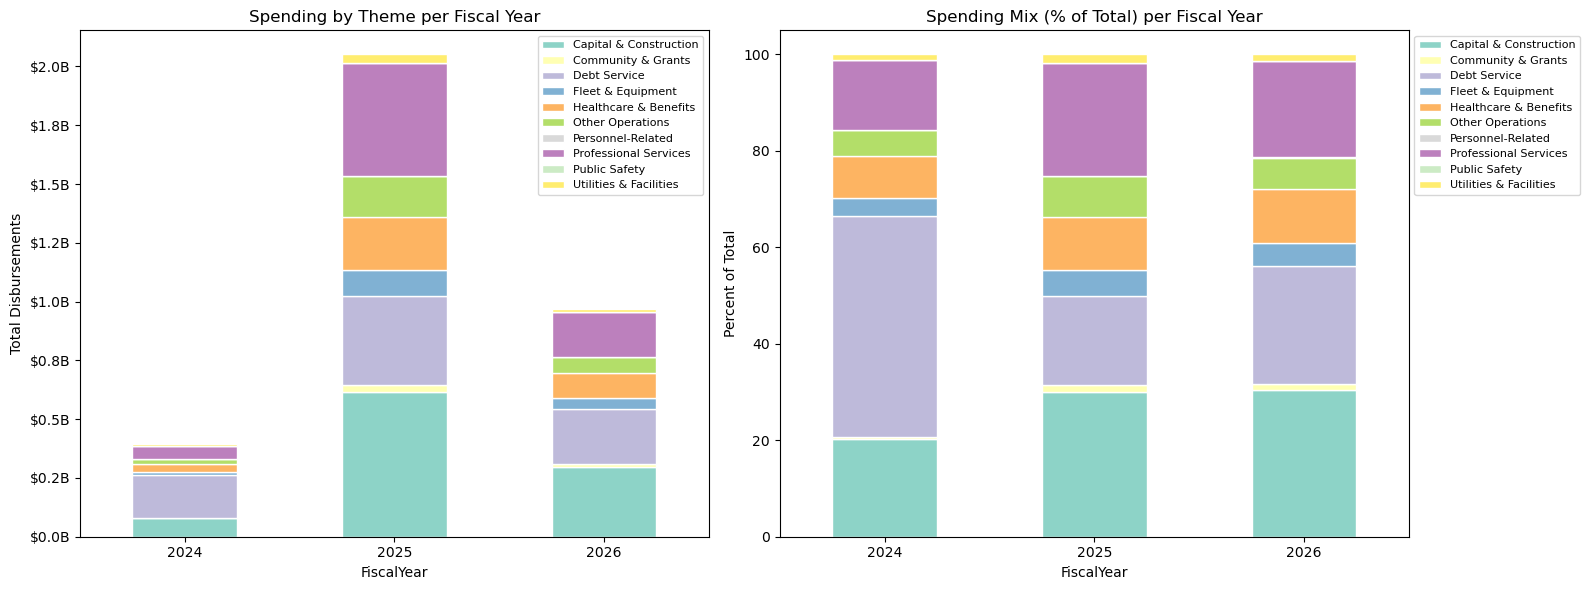

  FY2024:  4,956 checks | $    392,439,450 | 2 months of data
  FY2025: 32,673 checks | $  2,051,184,970 | 12 months of data
  FY2026: 12,371 checks | $    969,930,088 | 5 months of data


In [12]:
# Year-over-year theme comparison
fy_theme = df.groupby(['FiscalYear', 'spending_theme'])['Payment Amount'].sum().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stacked bar — absolute
fy_theme.plot.bar(stacked=True, ax=axes[0], colormap='Set3', edgecolor='white')
axes[0].set_title('Spending by Theme per Fiscal Year')
axes[0].set_ylabel('Total Disbursements')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e9:.1f}B'))
axes[0].legend(bbox_to_anchor=(1.0, 1.0), fontsize=8)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Normalized — percentage shares
fy_theme_pct = fy_theme.div(fy_theme.sum(axis=1), axis=0) * 100
fy_theme_pct.plot.bar(stacked=True, ax=axes[1], colormap='Set3', edgecolor='white')
axes[1].set_title('Spending Mix (% of Total) per Fiscal Year')
axes[1].set_ylabel('Percent of Total')
axes[1].legend(bbox_to_anchor=(1.0, 1.0), fontsize=8)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

# Print counts per FY for context
fy_counts = df.groupby('FiscalYear').agg(
    checks=('Payment Amount', 'count'),
    total=('Payment Amount', 'sum'),
    months=('Month', 'nunique')
)
for fy, row in fy_counts.iterrows():
    print(f"  FY{fy}: {row['checks']:>6,.0f} checks | ${row['total']:>15,.0f} | {int(row['months'])} months of data")

## Negative Payments — Refunds, Corrections & Credits

Negative disbursements are unusual and worth investigating — they typically represent voided checks,
vendor refunds, or accounting corrections. Who's giving money *back* to the city?

In [13]:
negatives = df[df['Payment Amount'] < 0].copy()
print(f"Negative payments: {len(negatives):,} ({len(negatives)/len(df)*100:.1f}% of all checks)")
print(f"Total refunds/credits: ${negatives['Payment Amount'].sum():,.2f}\n")

print("Top 15 largest negative payments (refunds/corrections):")
print("="*90)
for _, row in negatives.nsmallest(15, 'Payment Amount').iterrows():
    print(f"  FY{row['FiscalYear']} {row['Month']:>10s}  ${row['Payment Amount']:>14,.2f}  "
          f"{row['Payee'][:30]:30s}  {row['Service'][:35]}")

print(f"\nTop services with negative payments:")
neg_by_svc = negatives.groupby('Service')['Payment Amount'].agg(['sum', 'count']).sort_values('sum')
for svc, row in neg_by_svc.head(10).iterrows():
    print(f"  ${row['sum']:>14,.2f}  ({int(row['count']):>3} checks)  {svc}")

Negative payments: 72 (0.1% of all checks)
Total refunds/credits: $-338,557.40

Top 15 largest negative payments (refunds/corrections):
  FY2025   February  $   -146,710.79  VERINT AMERICAS INC             Computer Software Maintenance
  FY2024  September  $    -81,450.00  PROFORCE MARKETING I            Ammunition
  FY2025   November  $    -39,988.14  EDGEWOOD ISD                    Contractual Services
  FY2025   December  $    -12,850.00  PROMASTERS REMODELIN            Contributions to Other Agencies
  FY2025   February  $    -11,250.04  GRAYBAR ELECTRIC CO             Capital Outlay<5000 - Computer Equi
  FY2024  September  $     -7,354.61  SAN ANTONIO ZOOLOGIC            Construction Cost
  FY2025       June  $     -6,194.85  TONI BARRIENTES                 Fees to Professional Contractors
  FY2025   February  $     -3,818.21  JOHNSON CONTROLS INC            Maintenance and Repair Building and
  FY2025        May  $     -3,150.00  CENTERLINE SUPPLY IN            Construction Cost

## Key Takeaways

**What disbursements tell us that budgets can't:**

1. **Vendor concentration** — A Gini coefficient close to 1.0 means a tiny fraction of vendors
   capture the vast majority of city dollars. This is normal (large construction firms, bond
   trustees, and healthcare providers dominate), but extreme concentration deserves scrutiny.

2. **The long tail** — Most checks are small (under \$10K), but the big ones drive total spending.
   A handful of multi-million dollar payments to bond trustees and construction firms account for
   a disproportionate share of all disbursements.

3. **Spending DNA** — The theme breakdown reveals San Antonio's actual priorities:
   capital construction, debt service, and healthcare dominate, with professional services
   and fleet/equipment as major supporting categories.

4. **Negative payments** — Refunds and corrections are a normal part of municipal accounting.
   Large negatives often indicate renegotiated contracts, overpayment recoveries, or voided checks.

5. **Budget vs. Reality** — Comparing these actuals against the adopted budget data
   (in `combined_budget_summary.csv`) would reveal where the city over- or under-spent
   relative to plan — a natural next step for this analysis.

---
## Part 2: Budget vs. Actual — Comparing Disbursements to the Adopted Budget

The disbursement dataset has **only FY2025 as a complete fiscal year** (all 12 months).
FY2024 has just Aug–Sep, and FY2026 has Oct–Feb. So we'll anchor this comparison on **FY2025**.

**Important caveat:** Disbursements (check payments to vendors) are a *subset* of total city spending.
They don't include payroll, internal transfers, or pension contributions — so we expect actual
disbursements to be *less* than total adopted appropriations. The value is in the *relative mix*.

In [14]:
# Load adopted budget data
budget = pd.read_csv('../data/processed/combined_budget_summary.csv')

# FY2025 Total All Funds appropriations (priority areas only, no totals/reserves/balances)
skip_prefixes = ['TOTAL APPROPRIATIONS', 'Subtotal Appropriations', 'GROSS ENDING',
                 'Reserve for', 'Reserves for', 'Financial Reserves',
                 'Transfers to', 'Amendments', '1 The total']

budget_fy25 = budget[
    (budget['section'] == 'appropriation') &
    (budget['fund'] == 'Total All Funds') &
    (budget['fiscal_year'] == 2025) &
    (~budget['line_item'].str.startswith(tuple(skip_prefixes)))
].copy()

# FY2025 disbursements
disb_fy25 = df[df['FiscalYear'] == 2025].copy()

print("FY2025 OVERVIEW")
print("=" * 60)
print(f"  Adopted budget (Total All Funds):  ${budget_fy25['amount'].sum():>15,.0f}")
print(f"  Actual disbursements:              ${disb_fy25['Payment Amount'].sum():>15,.0f}")
print(f"  Disbursement rate:                 {disb_fy25['Payment Amount'].sum() / budget_fy25['amount'].sum():.1%}")
print(f"\n  (Gap is payroll, pensions, internal transfers, encumbrances, etc.)")
print(f"\nAdopted budget by priority area:")
for _, r in budget_fy25.sort_values('amount', ascending=False).iterrows():
    print(f"  ${r['amount']:>14,.0f}  {r['line_item']}")

FY2025 OVERVIEW
  Adopted budget (Total All Funds):  $  3,096,385,169
  Actual disbursements:              $  2,051,184,970
  Disbursement rate:                 66.2%

  (Gap is payroll, pensions, internal transfers, encumbrances, etc.)

Adopted budget by priority area:
  $ 1,063,172,831  Public Safety
  $   506,095,886  Health and Human Services
  $   392,126,157  Debt Service
  $   244,178,418  Economic Development
  $   196,065,605  Streets and Infrastructure
  $   189,807,496  Convention, Tourism & Culture
  $   174,813,650  Environmental
  $   140,342,595  Neighborhood Services
  $   104,417,028  Administrative & Operational Excellence
  $    85,365,503  Parks and Recreation


### Mapping Disbursement Themes to Budget Priority Areas

The budget uses priority areas (Public Safety, Health & Human Services, etc.) while disbursements
have service categories. Let's build a crosswalk to compare them side by side.

In [15]:
# Map disbursement services to budget priority areas
# This is an approximate crosswalk — the two taxonomies don't align perfectly
priority_map = {
    'Public Safety': ['Ammunition', 'Uniforms', 'Detention', 'Police', 'Fire ',
                      'Towing', 'Prisoner', 'Forensic', 'Emergency'],
    'Health & Human Services': ['Health Benefits', 'Pharmacy', 'Medical', 'Drugs',
                                'Workers Compensation', 'Liability Claims', 'Human Services',
                                'Clinic', 'Immunization'],
    'Debt Service': ['Principal on Bonds', 'Interest Expense', 'Debt', 'Fiscal Agent'],
    'Streets & Infrastructure': ['Construction Cost', 'Paving', 'Engineering Fees',
                                 'CAPITAL PROGRAMS', 'Building and Improvements',
                                 'Streets', 'Traffic', 'Drainage'],
    'Environmental': ['Disposal Services', 'Solid Waste', 'Water ', 'Sewer',
                      'Environmental', 'Recycling', 'Stormwater'],
    'Parks & Recreation': ['Parks', 'Recreation', 'Athletic', 'Swimming',
                           'Golf', 'Greenway'],
    'Economic Development': ['Economic Development', 'Workforce', 'Small Business',
                             'Incentive'],
    'Convention & Tourism': ['Convention', 'Tourism', 'Hotel', 'Visit San Antonio',
                             'Alamodome', 'Airlines'],
    'Admin & Operations': ['Subscriptions to Computer', 'Office Supplies', 'Printing',
                           'Postage', 'Telephone', 'Consulting', 'Legal Services',
                           'Rental of Facilities', 'Janitorial'],
}

def classify_priority(service):
    for area, keywords in priority_map.items():
        if any(kw.lower() in service.lower() for kw in keywords):
            return area
    return 'Other / Unclassified'

disb_fy25['budget_area'] = disb_fy25['Service'].apply(classify_priority)

# Aggregate disbursements by budget area
disb_by_area = disb_fy25.groupby('budget_area')['Payment Amount'].sum().sort_values(ascending=False)

# Build comparison table
budget_areas = budget_fy25.set_index('line_item')['amount'].to_dict()

# Normalize budget area names for matching
name_normalize = {
    'Public Safety': 'Public Safety',
    'Health & Human Services': 'Health and Human Services',
    'Debt Service': 'Debt Service',
    'Streets & Infrastructure': 'Streets and Infrastructure',
    'Environmental': 'Environmental',
    'Parks & Recreation': 'Parks and Recreation',
    'Economic Development': 'Economic Development',
    'Convention & Tourism': 'Convention, Tourism & Culture',
    'Admin & Operations': 'Administrative & Operational Excellence',
}

print(f"{'Priority Area':<28s} {'Budget (Adopted)':>18s} {'Disbursed (Actual)':>18s} {'Disb. Rate':>12s}")
print("=" * 80)
total_budget = 0
total_disb = 0
rows_for_plot = []
for area in priority_map.keys():
    budget_name = name_normalize.get(area, area)
    b = budget_areas.get(budget_name, 0)
    d = disb_by_area.get(area, 0)
    rate = f"{d/b:.0%}" if b > 0 else "n/a"
    print(f"  {area:<26s} ${b:>15,.0f}  ${d:>15,.0f}  {rate:>10s}")
    total_budget += b
    total_disb += d
    rows_for_plot.append({'area': area, 'budget': b, 'disbursed': d})

other_disb = disb_by_area.get('Other / Unclassified', 0)
print(f"  {'Other / Unclassified':<26s} {'—':>16s}  ${other_disb:>15,.0f}")
total_disb += other_disb
print("-" * 80)
print(f"  {'TOTAL':<26s} ${total_budget:>15,.0f}  ${total_disb:>15,.0f}  {total_disb/total_budget:.0%}")

compare_df = pd.DataFrame(rows_for_plot)

Priority Area                  Budget (Adopted) Disbursed (Actual)   Disb. Rate
  Public Safety              $  1,063,172,831  $      1,527,302          0%
  Health & Human Services    $    506,095,886  $    226,732,634         45%
  Debt Service               $    392,126,157  $    375,138,766         96%
  Streets & Infrastructure   $    196,065,605  $    613,877,728        313%
  Environmental              $    174,813,650  $     13,731,012          8%
  Parks & Recreation         $     85,365,503  $        440,446          1%
  Economic Development       $    244,178,418  $              0          0%
  Convention & Tourism       $    189,807,496  $              0          0%
  Admin & Operations         $    104,417,028  $     45,888,212         44%
  Other / Unclassified                      —  $    773,848,870
--------------------------------------------------------------------------------
  TOTAL                      $  2,956,042,574  $  2,051,184,970  69%


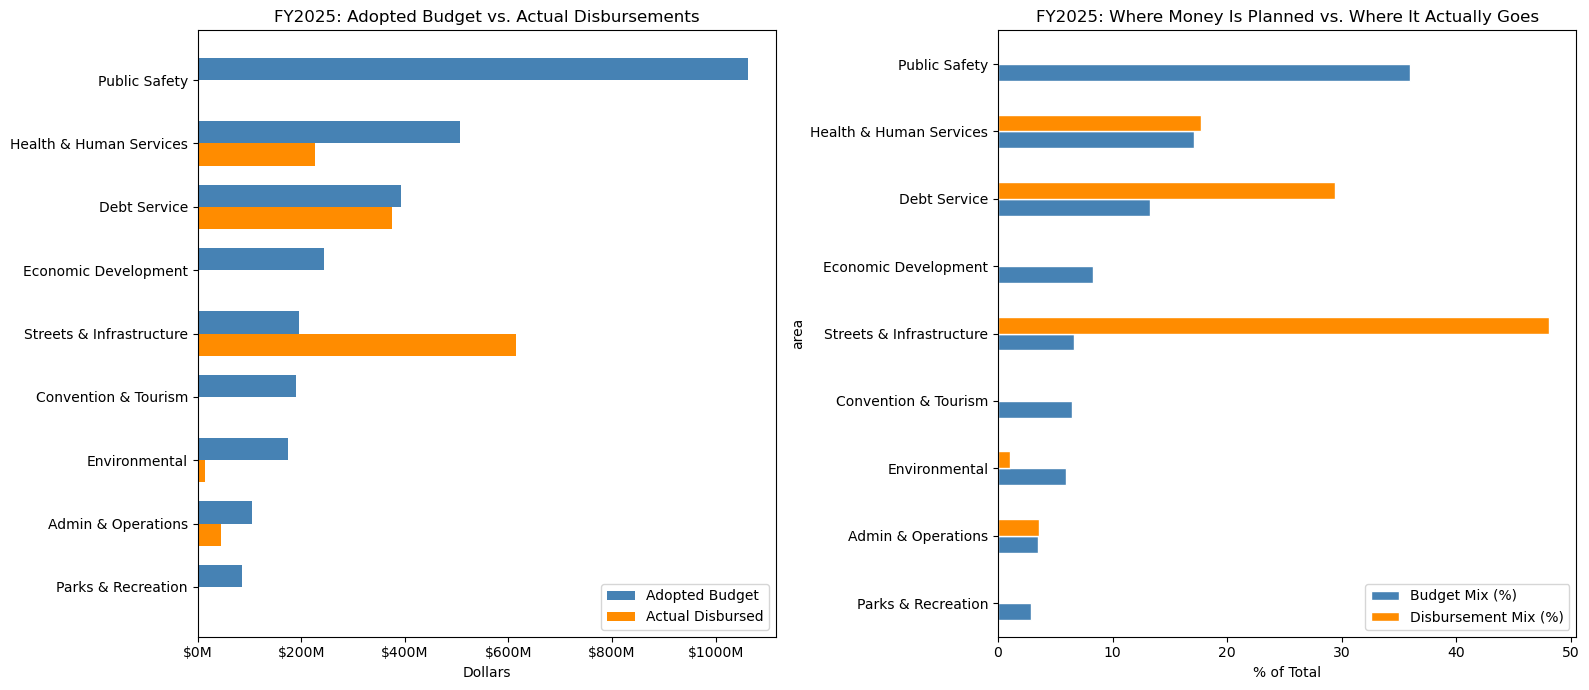

In [16]:
# Side-by-side comparison chart
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Left: Grouped bar chart (Budget vs Actual) ---
compare_plot = compare_df.sort_values('budget', ascending=True)
y = range(len(compare_plot))
h = 0.35

axes[0].barh([i + h/2 for i in y], compare_plot['budget'], h, label='Adopted Budget', color='steelblue')
axes[0].barh([i - h/2 for i in y], compare_plot['disbursed'], h, label='Actual Disbursed', color='darkorange')
axes[0].set_yticks(list(y))
axes[0].set_yticklabels(compare_plot['area'])
axes[0].set_xlabel('Dollars')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
axes[0].set_title('FY2025: Adopted Budget vs. Actual Disbursements')
axes[0].legend(loc='lower right')

# --- Right: Spending mix comparison (% of total) ---
budget_pct = compare_df.set_index('area')['budget'] / compare_df['budget'].sum() * 100
disb_pct = compare_df.set_index('area')['disbursed'] / compare_df['disbursed'].sum() * 100

mix = pd.DataFrame({'Budget Mix (%)': budget_pct, 'Disbursement Mix (%)': disb_pct}).sort_values('Budget Mix (%)', ascending=True)
mix.plot.barh(ax=axes[1], color=['steelblue', 'darkorange'], edgecolor='white')
axes[1].set_xlabel('% of Total')
axes[1].set_title('FY2025: Where Money Is Planned vs. Where It Actually Goes')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

### FY2026 Pace Check — Is the City On Track?

Even though FY2026 only has 5 months of data (Oct–Feb), we can project a full-year pace
and compare it to the FY2026 adopted budget.

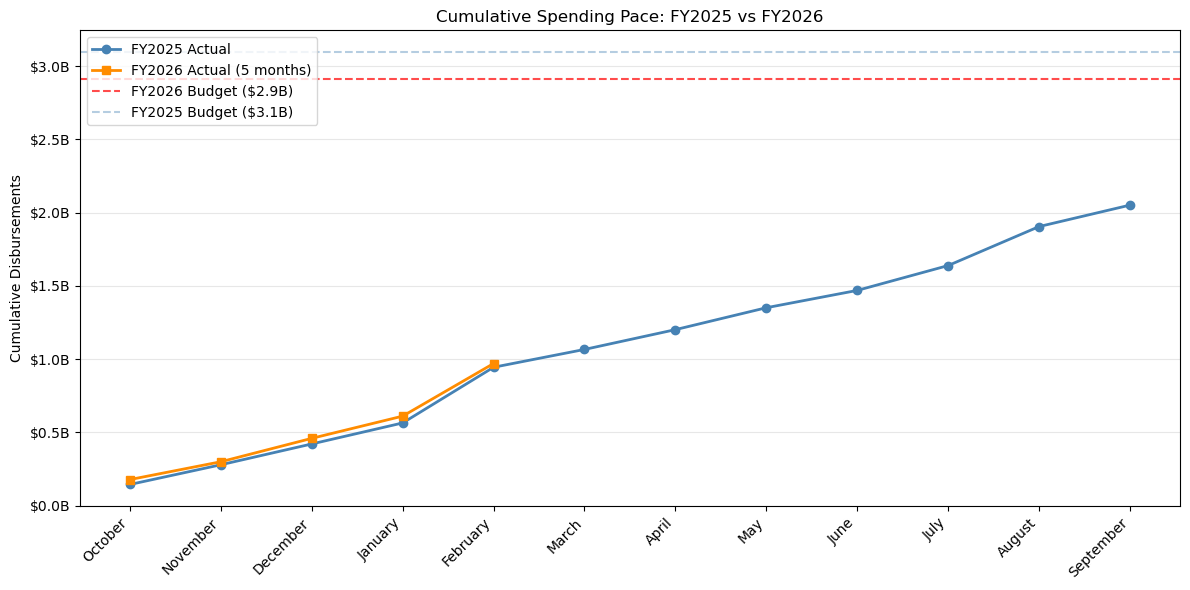

FY2026 PACE CHECK (5 months elapsed)
  Spent so far:       $    969,930,088
  12-month projection: $  2,327,832,212
  Adopted budget:     $  2,909,242,730
  Projected vs budget: 80%

  FY2025 comparison:
  FY2025 first 5 mos:  $    944,440,451
  FY2026 first 5 mos:  $    969,930,088
  YoY change:          +2.7%


In [17]:
# FY2026 pace analysis
disb_fy26 = df[df['FiscalYear'] == 2026]
months_elapsed_26 = disb_fy26['Month'].nunique()  # 5 months
fy26_actual = disb_fy26['Payment Amount'].sum()
fy26_projected = fy26_actual / months_elapsed_26 * 12

# FY2026 budget
budget_fy26 = budget[
    (budget['section'] == 'appropriation') &
    (budget['fund'] == 'Total All Funds') &
    (budget['fiscal_year'] == 2026) &
    (~budget['line_item'].str.startswith(tuple(skip_prefixes)))
]
fy26_budget = budget_fy26['amount'].sum()

# FY2025 comparison baseline
fy25_actual = disb_fy25['Payment Amount'].sum()
fy25_budget = budget_fy25['amount'].sum()

# Monthly cumulative spending comparison: FY2025 vs FY2026
month_order = ['October','November','December','January','February','March',
               'April','May','June','July','August','September']

fy25_monthly = df[df['FiscalYear']==2025].groupby('Month')['Payment Amount'].sum().reindex(month_order)
fy26_monthly = df[df['FiscalYear']==2026].groupby('Month')['Payment Amount'].sum().reindex(month_order)

fy25_cumulative = fy25_monthly.cumsum()
fy26_cumulative = fy26_monthly.cumsum()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(range(12), fy25_cumulative.values, 'o-', color='steelblue', linewidth=2, markersize=6, label='FY2025 Actual')
ax.plot(range(len(fy26_cumulative.dropna())), fy26_cumulative.dropna().values, 's-',
        color='darkorange', linewidth=2, markersize=6, label='FY2026 Actual (5 months)')
ax.axhline(y=fy26_budget, color='red', linestyle='--', alpha=0.7, label=f'FY2026 Budget (${fy26_budget/1e9:.1f}B)')
ax.axhline(y=fy25_budget, color='steelblue', linestyle='--', alpha=0.4, label=f'FY2025 Budget (${fy25_budget/1e9:.1f}B)')

ax.set_xticks(range(12))
ax.set_xticklabels(month_order, rotation=45, ha='right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e9:.1f}B'))
ax.set_ylabel('Cumulative Disbursements')
ax.set_title('Cumulative Spending Pace: FY2025 vs FY2026')
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"FY2026 PACE CHECK ({months_elapsed_26} months elapsed)")
print("=" * 55)
print(f"  Spent so far:       ${fy26_actual:>15,.0f}")
print(f"  12-month projection: ${fy26_projected:>15,.0f}")
print(f"  Adopted budget:     ${fy26_budget:>15,.0f}")
print(f"  Projected vs budget: {fy26_projected/fy26_budget:.0%}")
print(f"\n  FY2025 comparison:")
print(f"  FY2025 first 5 mos:  ${fy25_cumulative.iloc[4]:>15,.0f}")
print(f"  FY2026 first 5 mos:  ${fy26_actual:>15,.0f}")
print(f"  YoY change:          {(fy26_actual - fy25_cumulative.iloc[4]) / fy25_cumulative.iloc[4]:>+.1%}")

### Historical Budget Trend vs. Disbursement Reality

Let's zoom out and see how the adopted budget has grown over time, and where FY2025 actual
disbursements land relative to that trend.

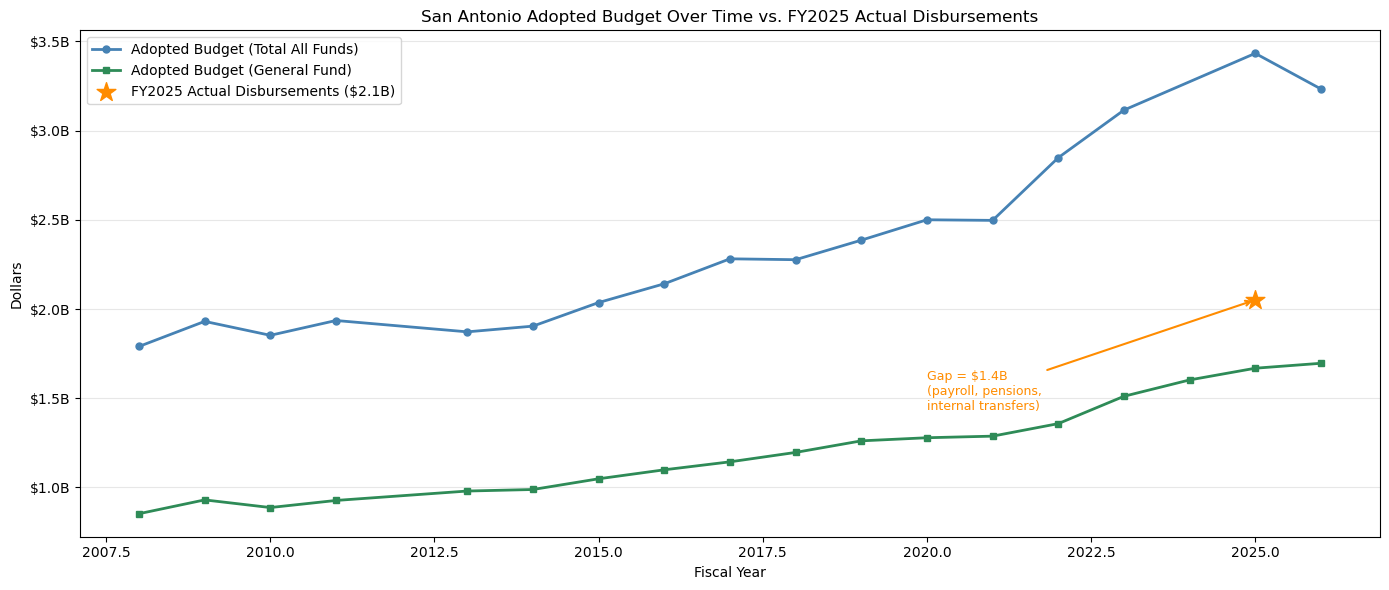

Key insight: Disbursements represent vendor payments only.
The gap between budget and disbursements is NOT underspending —
it's the portion of the budget that goes to payroll, pensions,
internal transfers, and other non-vendor expenditures.


In [18]:
# Historical adopted budget totals (Total All Funds)
hist_budget = budget[
    (budget['section'] == 'appropriation') &
    (budget['fund'] == 'Total All Funds') &
    (budget['line_item'] == 'TOTAL APPROPRIATIONS')
].groupby('fiscal_year')['amount'].sum()

# Also get General Fund totals
hist_gf = budget[
    (budget['section'] == 'appropriation') &
    (budget['fund'] == 'General Fund') &
    (budget['line_item'] == 'TOTAL APPROPRIATIONS')
].groupby('fiscal_year')['amount'].sum()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(hist_budget.index, hist_budget.values, 'o-', color='steelblue', linewidth=2,
        markersize=5, label='Adopted Budget (Total All Funds)')
ax.plot(hist_gf.index, hist_gf.values, 's-', color='seagreen', linewidth=2,
        markersize=5, label='Adopted Budget (General Fund)')

# Mark FY2025 actual disbursements
ax.scatter([2025], [fy25_actual], color='darkorange', s=200, zorder=5, marker='*',
           label=f'FY2025 Actual Disbursements (${fy25_actual/1e9:.1f}B)')

# Annotate the gap
ax.annotate(f'Gap = ${(hist_budget.get(2025,0) - fy25_actual)/1e9:.1f}B\n(payroll, pensions,\ninternal transfers)',
            xy=(2025, fy25_actual), xytext=(2020, fy25_actual * 0.7),
            fontsize=9, color='darkorange',
            arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.5))

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e9:.1f}B'))
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Dollars')
ax.set_title('San Antonio Adopted Budget Over Time vs. FY2025 Actual Disbursements')
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Key insight: Disbursements represent vendor payments only.")
print("The gap between budget and disbursements is NOT underspending —")
print("it's the portion of the budget that goes to payroll, pensions,")
print("internal transfers, and other non-vendor expenditures.")